In [1]:
# Task 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Task 2: Load the milk production dataset

df = pd.read_csv("monthly_milk_production.csv")

print(df.head())

      Date  Production
0  1962-01         589
1  1962-02         561
2  1962-03         640
3  1962-04         656
4  1962-05         727


In [3]:
# Task 3: Display dataset information

print(df.info())

print(df.shape)

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB
None
(168, 2)
       Production
count  168.000000
mean   754.708333
std    102.204524
min    553.000000
25%    677.750000
50%    761.000000
75%    824.500000
max    969.000000


In [4]:
# Task 4: Check missing values

print(df.isnull().sum())

Date          0
Production    0
dtype: int64


In [5]:
# Task 5: Convert date column into datetime format

df.iloc[:,0] = pd.to_datetime(df.iloc[:,0])

df.set_index(df.columns[0], inplace=True)

print(df.head())

            Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727


C:\Users\AARYAN\anaconda3\Lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


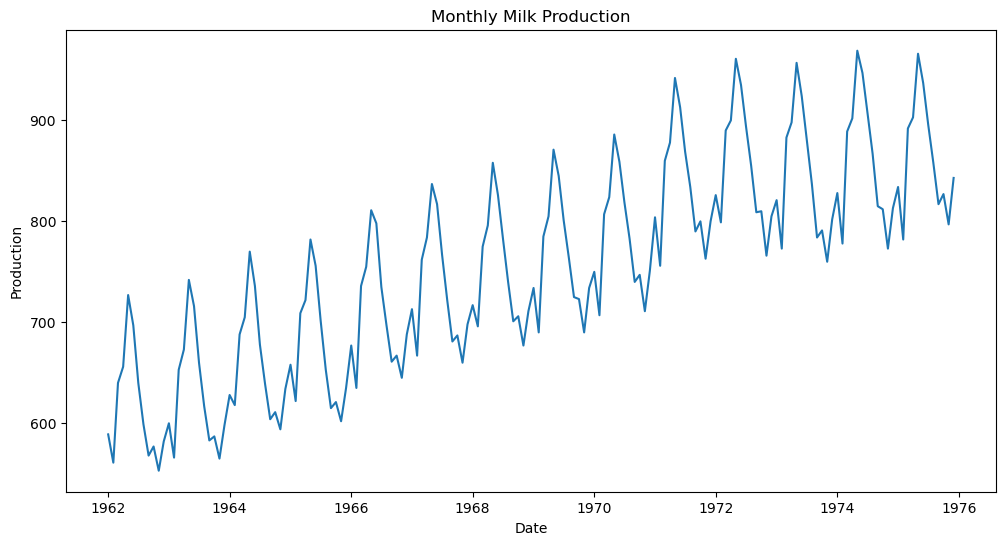

In [6]:
# Task 6: Visualize monthly milk production trend

plt.figure(figsize=(12,6))

plt.plot(df)

plt.title("Monthly Milk Production")

plt.xlabel("Date")

plt.ylabel("Production")

plt.show()

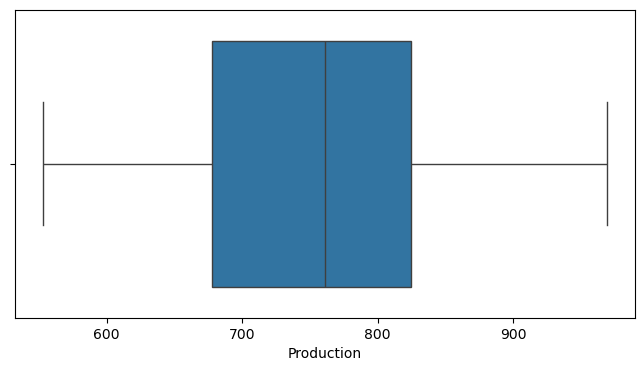

In [9]:
# Task 7: Detect outliers using boxplot
import seaborn as sns
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Production'])

plt.show()

In [11]:
# Task 8: Scale data using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

print(scaled_data[:5])

[[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]]


In [12]:
# Task 9: Create input-output sequences

def create_dataset(data, window_size=12):

    X = []
    y = []

    for i in range(len(data)-window_size):

        X.append(data[i:i+window_size])

        y.append(data[i+window_size])

    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data, 12)

print(X.shape)

print(y.shape)

(156, 12, 1)
(156, 1)


In [13]:
# Task 10: Split dataset into train and test sets

train_size = int(len(X)*0.8)

X_train = X[:train_size]

X_test = X[train_size:]

y_train = y[:train_size]

y_test = y[train_size:]

In [16]:
# Task 11: Build and train Simple RNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        50,
        activation='relu',
        input_shape=(X_train.shape[1],1)
    )
)

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2319
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0323
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0246
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0199
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0167
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0127
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0106
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0105
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0056
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0034
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0045
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0032
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0033
Epoch 14/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026
Epoch 15/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0035
Epoch 16/50
16/16 ━

In [26]:
# Task 12: Build and train LSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        50,
        activation='relu',
        input_shape=(X_train.shape[1],1)
    )
)

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

history = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=1
)

C:\Users\AARYAN\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1448
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0438
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0245
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0241
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0230
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0222
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0208
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0200
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0196
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0181
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0163
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0155
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0131
Epoch 14/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0113
Epoch 15/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0105
Epoch 16/50
16/16

In [27]:
# Task 13: Build and train GRU model

gru_model = Sequential()

gru_model.add(
    GRU(
        50,
        activation='relu',
        input_shape=(X_train.shape[1],1)
    )
)

gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

gru_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=1
)

C:\Users\AARYAN\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.1712
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0540
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0258
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0245
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0228
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0221
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0213
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0211
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0204
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0197
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0191
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0186
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0182
Epoch 14/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0176
Epoch 15/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0172
Epoch

In [28]:
# Task 14: Generate predictions from all models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

rnn_pred = rnn_model.predict(X_test)

lstm_pred = lstm_model.predict(X_test)

gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step


In [29]:
# Task 15: Calculate RMSE and MAE values

for name,pred in zip(
    ['RNN','LSTM','GRU'],
    [rnn_pred,lstm_pred,gru_pred]
):

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    mae = mean_absolute_error(
        y_test,
        pred
    )

    print(name)

    print("RMSE =",rmse)

    print("MAE =",mae)

RNN
RMSE = 0.05983159425536025
MAE = 0.04813964965824894
LSTM
RMSE = 0.05573152591238167
MAE = 0.046734683072337725
GRU
RMSE = 0.0823191768182195
MAE = 0.06333170888515616


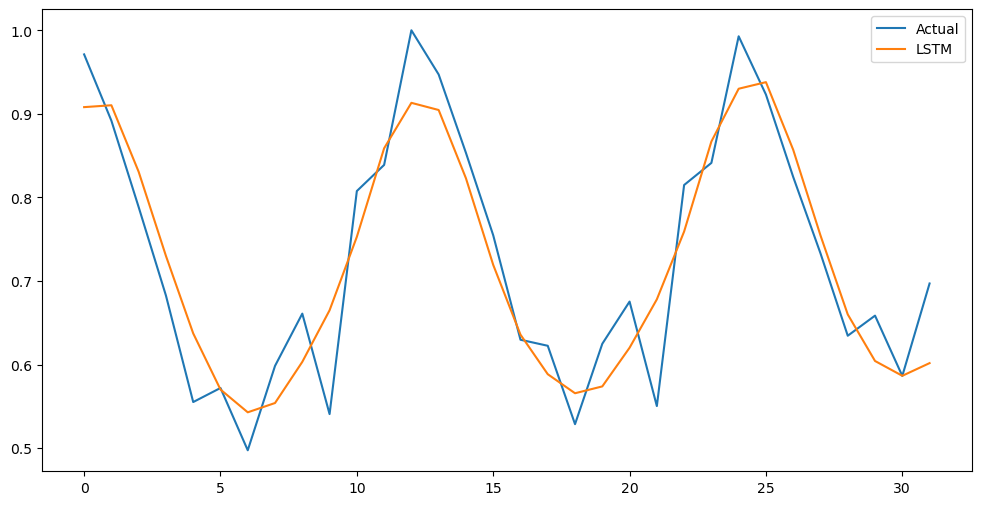

In [30]:
# Task 16: Plot actual versus predicted values

plt.figure(figsize=(12,6))

plt.plot(y_test,label='Actual')

plt.plot(lstm_pred,label='LSTM')

plt.legend()

plt.show()

In [31]:
# Task 17: Forecast milk production for next 12 months

forecast = []

current_batch = X[-1].reshape(1,12,1)

for i in range(12):

    pred = lstm_model.predict(current_batch)[0]

    forecast.append(pred)

    current_batch = np.append(
        current_batch[:,1:,:],
        [[pred]],
        axis=1
    )

print(forecast)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
[array([0.60184985], dtype=float32), array([0.629093], dtype=float32), array([0.6661666], dtype=float32), array([0.7846036], dtype=float32), array([0.85934687], dtype=float32), array([0.91518974], dtype=float32), array([0.8876046], dtype=float32), array([0.8149414], dtype=float32), array([0.7353184], dtype=float32), array([0.6666923], dtype=float32), array([0.6210403], dtype=float32), array([0.5862272], dtype=float32)]


In [ ]:
# Task 18: Visualize future milk production forecast

plt.figure(figsize=(10,5))

plt.plot(forecast)

plt.title("Next 12 Months Forecast")

plt.show()